<a href="https://colab.research.google.com/github/JosMirBonito/Usi-DI-SEMANA2/blob/main/S03_ACTIVIDAD_1_DISE%C3%91O.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importamos librerías necesarias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Cargamos el dataset Housing desde una URL

url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

housing = pd.read_csv(url)

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [ ]:
# Mostrar información general del dataset

housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [ ]:
# Cantidad de valores faltantes por columna

housing.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [ ]:
# Rellenar valores faltantes con la mediana

median_bedrooms = housing["total_bedrooms"].median()

housing["total_bedrooms"].fillna(
    median_bedrooms,
    inplace=True
)

/tmp/ipykernel_11504/4192345611.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  housing["total_bedrooms"].fillna(


In [ ]:
# Convertir ocean_proximity en variables numéricas

housing = pd.get_dummies(
    housing,
    columns=["ocean_proximity"]
)

housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_<1H OCEAN   20640 non-null  bool   
 10  ocean_proximity_INLAND      20640 non-null  bool   
 11  ocean_proximity_ISLAND      20640 non-null  bool   
 12  ocean_proximity_NEAR BAY    20640 non-null  bool   
 13  ocean_proximity_NEAR OCEAN  206

In [ ]:
# Variables independientes

X = housing.drop(
    "median_house_value",
    axis=1
)

# Variable objetivo

y = housing["median_house_value"]

In [ ]:
# Separación de datos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# Crear modelo

modelo = LinearRegression()


# Entrenar modelo

modelo.fit(
    X_train,
    y_train
)

LinearRegression()

In [ ]:
# Predicciones

y_pred = modelo.predict(X_test)


# Evaluación del modelo

mse = mean_squared_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)


print("Mean Squared Error (MSE):", mse)
print("R²:", r2)

Mean Squared Error (MSE): 4908476721.156623
R²: 0.6254240620553602


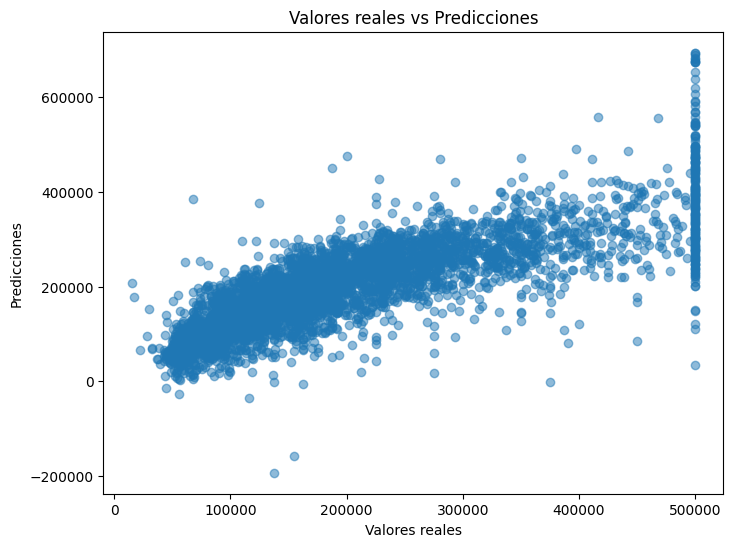

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.xlabel("Valores reales")
plt.ylabel("Predicciones")

plt.title(
    "Valores reales vs Predicciones"
)

plt.show()

In [ ]:
import joblib

# Guardar modelo

joblib.dump(
    modelo,
    "modelo_regresion.pkl"
)

['modelo_regresion.pkl']

In [ ]:
# Cargar modelo guardado

modelo_cargado = joblib.load(
    "modelo_regresion.pkl"
)